<ipython-input-32-89bce8431a87>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ka['new_cases'].fillna(df_ka['new_cases'].median(), inplace=True)


Using device: cuda
Epoch 0/70, Train Loss: 0.0042, Test Loss: 0.0106
Epoch 10/70, Train Loss: 0.0023, Test Loss: 0.0167
Epoch 20/70, Train Loss: 0.0019, Test Loss: 0.0085
Epoch 30/70, Train Loss: 0.0019, Test Loss: 0.0181
Epoch 40/70, Train Loss: 0.0018, Test Loss: 0.0313
Epoch 50/70, Train Loss: 0.0018, Test Loss: 0.3323
Epoch 60/70, Train Loss: 0.0018, Test Loss: 0.0394
Forecast saved as 'kazakhstan_covid_forecast.csv'


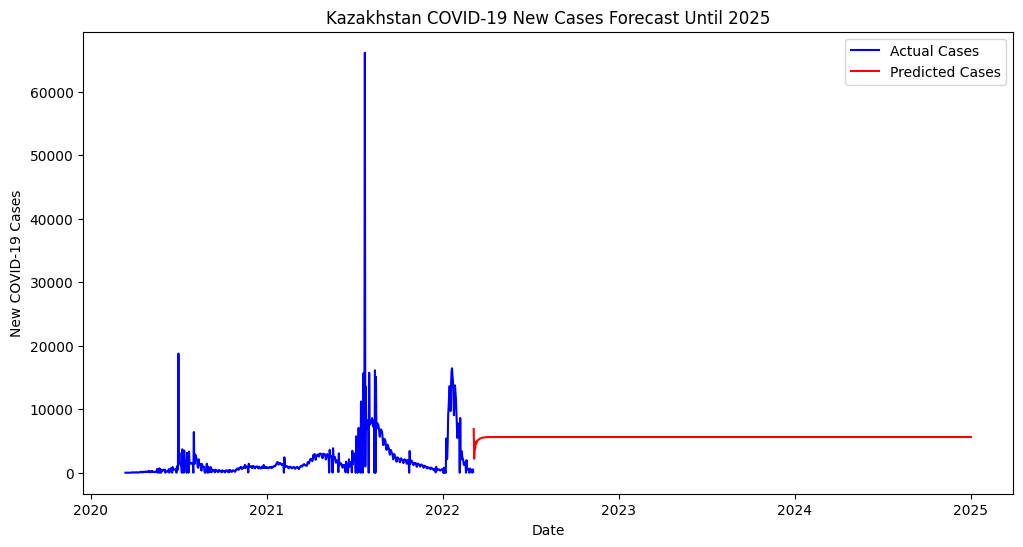

In [32]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

df = pd.read_csv("owid-covid-data.csv")

# Filter data for Kazakhstan
df_ka = df[df['location'] == 'Kazakhstan'].copy()
df_ka['date'] = pd.to_datetime(df_ka['date'])
df_ka = df_ka[['date', 'new_cases']].copy()

df_ka['new_cases'].fillna(df_ka['new_cases'].median(), inplace=True)
df_ka.sort_values('date', inplace=True)

# 2. Normalize the Data Using Min-Max Scaler

scaler = MinMaxScaler()
df_ka['new_cases_scaled'] = scaler.fit_transform(df_ka[['new_cases']])

series = df_ka['new_cases_scaled'].values


# 3. Create Sliding Windows (window = 30)


window = 30

def create_windows(series, window):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)

X_all, y_all = create_windows(series, window)


# 4. Split the Data into Train and Test Sets (Last 2 months as test)


test_size = 60
train_size = len(y_all) - test_size

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test, y_test   = X_all[train_size:], y_all[train_size:]


# 5. Create a PyTorch Dataset for Time Series Data


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# 6. Define the LSTM Model Architecture


class LSTMForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.25):
        super(LSTMForecast, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = LSTMForecast().to(device)


# 7. Train the Model Using MSELoss


criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 70  # Adjustable

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Evaluation on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    test_loss /= len(test_loader.dataset)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")


# 8. Forecast Future New Cases Until 2025


last_window = series[-window:]
predictions = []
current_window = last_window.copy()

last_date = df_ka['date'].max()
target_date = pd.to_datetime('2025-01-01')
current_date = last_date
future_dates = []

while current_date < target_date:
    input_seq = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
    model.eval()
    with torch.no_grad():
        pred = model(input_seq)
    pred_value = pred.item()
    predictions.append(pred_value)
    current_window = np.append(current_window[1:], pred_value)
    current_date += pd.Timedelta(days=1)
    future_dates.append(current_date)

predictions_inversed = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

forecast_df = pd.DataFrame({'date': future_dates, 'predicted_new_cases': predictions_inversed})

# Save forecast
forecast_df.to_csv("kazakhstan_covid_forecast.csv", index=False)
print("Forecast saved as 'kazakhstan_covid_forecast.csv'")




plt.figure(figsize=(12, 6))
plt.plot(df_ka['date'], df_ka['new_cases'], label='Actual Cases', color='blue')
plt.plot(forecast_df['date'], forecast_df['predicted_new_cases'], label='Predicted Cases', color='red')
plt.xlabel("Date")
plt.ylabel("New COVID-19 Cases")
plt.title("Kazakhstan COVID-19 New Cases Forecast Until 2025")
plt.legend()
plt.show()


In [33]:
forecast_df.head()

,date,predicted_new_cases
0,2022-03-06,6879.127149
1,2022-03-07,2200.235441
2,2022-03-08,4916.907197
3,2022-03-09,3812.030822
4,2022-03-10,4751.955615


Normalization:

The MinMaxScaler scales the new_cases values to a range between 0 and 1.
This scaling helps improve the training stability and speed of the neural network.

Sequence Creation (Sliding Window):

A sliding window of 30 days is used to generate input sequences (X_all) and their corresponding target values (y_all).
For each position in the time series (starting from day 30), the preceding 30 days become the input, and the following day is the target for prediction.

Splitting into Training and Testing Sets:

The sequences are split so that the last 60 days are used as the test set, while the remaining sequences are used for training.

PyTorch Dataset and DataLoader:

A custom TimeSeriesDataset is created to convert the data into tensors.
DataLoaders batch and (if needed) shuffle the data, which makes training more efficient.

PyTorch Dataset and DataLoader

Custom TimeSeriesDataset

Purpose:

The custom TimeSeriesDataset class is created to encapsulate the logic for how your time series data is stored and accessed during training. By inheriting from torch.utils.data.Dataset, you can easily integrate your data with PyTorch’s training loop.


Data Conversion:

In the dataset's __init__ method, the raw NumPy arrays (X and y) are converted into PyTorch tensors. This conversion is crucial because PyTorch’s models and optimizers expect data in tensor format. Additionally, an extra dimension is added (using unsqueeze(-1)) to ensure the input shape matches the model’s expected format:


Shape:
For an LSTM, the typical input shape is (batch_size, sequence_length, input_size).

By unsqueezing, you convert an array of shape (samples, sequence_length) into (samples, sequence_length, 1), which means you have one feature per time step.

len and getitem Methods:

The __len__ method returns the number of samples in the dataset, and __getitem__ fetches a single sample (both the input sequence and its corresponding target). This standard interface allows PyTorch to automatically iterate over the dataset during training.


DataLoader

Batching:

The DataLoader takes an instance of your custom Dataset and provides the data in mini-batches. Batching is essential because it allows the model to update its weights after processing a subset of data, making training more efficient in terms of computation and memory usage.


Shuffling:

Shuffling the data (enabled by setting shuffle=True in the training loader) is important for stochastic gradient descent. It helps break any potential order in the training data that could bias the learning process. In contrast, for the test loader, shuffling is typically disabled because you want to evaluate the model on data in a consistent order.


Parallel Data Loading:

Although not explicitly used in this code snippet, the DataLoader can also load data in parallel using multiple workers. This can further speed up the training process by overlapping data preprocessing with model training.



Model Architecture:

The LSTM model (LSTMForecast) consists of 2 LSTM layers, followed by Batch Normalization, ReLU activation, Dropout layers, and 2 fully connected layers.
This architecture is designed to capture temporal dependencies and produce a robust forecast.

Training the Model:

The model is trained for 70 epochs using Mean Squared Error (MSE) as the loss function and the Adam optimizer.
During each epoch, the training loss is calculated and, periodically, the test loss is printed for monitoring.

Forecasting Future Values:

Starting from the last available 30-day window, the model forecasts each subsequent day recursively until January 1, 2025.
Each forecasted value is appended to the window, which is then used for the next prediction.
The normalized predictions are inverse-transformed to recover the original scale of new cases.

Plotting:

The code plots the actual new cases against the forecasted new cases to visualize how the model predicts the future trend.


Multiple Layers:
In the LSTMForecast model, two LSTM layers are used (controlled by the num_layers=2 parameter). Stacking LSTM layers allows the network to learn more complex features from the input data:

Lower Layers: Capture basic temporal patterns.
Higher Layers: Learn more abstract and high-level representations of the sequence.
Batch Normalization
Purpose:
Batch normalization is applied to the output of the LSTM layers (specifically, to the output of the last time step). It standardizes the inputs to a layer, which can help stabilize and speed up training by reducing internal covariate shift.


Placement:

After extracting the last time step’s output from the LSTM, the output is normalized. This normalization ensures that the subsequent activation functions (like ReLU) receive inputs that are on a similar scale, which can improve training performance.

ReLU Activation

Role of ReLU:
The Rectified Linear Unit (ReLU) activation function introduces non-linearity into the model. This non-linearity allows the network to learn complex patterns in the data. ReLU is applied after batch normalization and again after the first fully connected layer.

Dropout Layers
Preventing Overfitting:

Dropout is a regularization technique where a random subset of neurons is “dropped” (i.e., temporarily set to zero) during each training iteration. This prevents the model from relying too much on any single neuron and encourages the network to learn redundant representations that generalize better.

Usage:

In this architecture, dropout is applied twice:

Once after the activation following the LSTM output.
Once after the activation of the first fully connected layer. This helps to reduce overfitting at different stages of the network.

Fully Connected Layers (Linear Layers)

Mapping to Output:

The fully connected layers (often called Linear layers) take the high-level features extracted by the LSTM layers and transform them into the final prediction:

fc1: Maps the high-dimensional feature vector from the LSTM to a smaller hidden representation (32 neurons in this case).

fc2: Takes the output of fc1 and produces the final forecast (a single value representing the predicted new case count).

Why Two Layers?

Using two layers allows the network to refine its predictions. The first linear layer reduces the dimensionality and learns intermediate representations, and the second layer combines those representations to produce a final output.


LSTMForecast Model Architecture:
The architecture leverages multiple LSTM layers to capture temporal dependencies, applies batch normalization and dropout to stabilize training and reduce overfitting, uses ReLU activations to introduce non-linearity, and finally maps the extracted features through two fully connected layers to produce a forecast. This combination is designed to effectively model complex time series data and produce robust predictions.

These design choices help the model learn from the historical patterns in the COVID-19 case data and generate forecasts that can be used for planning and analysis.

In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


df = pd.read_csv("owid-covid-data.csv")

df_ka = df[df['location'] == 'Kazakhstan'].copy()
df_ka['date'] = pd.to_datetime(df_ka['date'])

# Select only the 'date' and 'new_cases' columns.
df_ka = df_ka[['date', 'new_cases']].copy()

# Replace missing values in 'new_cases' with the median of the column.
df_ka['new_cases'].fillna(df_ka['new_cases'].median(), inplace=True)

# Sort the dataframe by date to ensure the time series is in chronological order.
df_ka.sort_values('date', inplace=True)



<ipython-input-16-217a60a87b2f>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ka['new_cases'].fillna(df_ka['new_cases'].median(), inplace=True)


In [17]:
# 2. Normalize the Data Using Min-Max Scaler
# ------------------------------------------
# Normalization helps the neural network train faster and more effectively.
scaler = MinMaxScaler()
df_ka['new_cases_scaled'] = scaler.fit_transform(df_ka[['new_cases']])
series = df_ka['new_cases_scaled'].values

In [18]:
# 3. Create Sliding Windows (window size = 30)
# --------------------------------------------
# The sliding window approach creates sequences where each input (X) consists of the past 30 days,
# and the target (y) is the value for the next day.
window = 30
def create_windows(series, window):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])  # Past 30 days as input.
        y.append(series[i])           # The next day as target.
    return np.array(X), np.array(y)

X_all, y_all = create_windows(series, window)


Creating a Single Sequence Array:


The Artem’s function create_sequences loops over the time series and, for each index, extracts a sequence of 30 consecutive values.

It returns a single array where each element (row) is a full sequence of 30 values.

Slicing the Array:


After creating the sequences, the code manually splits each sequence into:

Input (X): All values except the last one (i.e., the first 29 days).
Target (y): The last value in the sequence (i.e., the 30th day).

This is done using:

X = sequences[:, :-1]  # All but the last element of each sequence
y = sequences[:, -1]   # The last element of each sequence

This Code’s Approach

Directly Separating Inputs and Targets:


The custom function create_windows does the splitting within the loop.

For each position in the series, it appends:

Input (X): The 30 days leading up to the current day.

Target (y): The current day (the day immediately following the 30-day window).

Resulting Arrays:


The function returns two separate arrays: one for all input sequences (X_all) and one for all corresponding targets (y_all).

This means that the separation between inputs and targets is handled as the sequences are built, rather than creating a combined array that needs to be split later.

Why This Matters

Clarity and Readability:

By directly separating inputs and targets in the loop, the process becomes more explicit. You know immediately which array holds the past 30 days (inputs) and which holds the target values.


Avoiding Additional Slicing:

The Artem’s method requires an extra slicing step after the full sequences are created. In contrast, our approach builds the two arrays simultaneously, which can reduce the risk of errors and make the code easier to understand.


Conceptual Difference:

Artem’s Code: First creates a full sequence (all 30 days together) and then slices off the target value.

This Code: Directly separates the process into building input windows (X_all) and their corresponding targets (y_all).

Both methods ultimately serve the same purpose, but the direct separation in our approach can be more straightforward when explaining the flow of data from raw time series to training inputs and targets.

In [19]:
# 4. Split the Data into Training and Testing Sets
# -------------------------------------------------
# Reserve the last 60 days (approximately 2 months) for testing.
test_size = 60
train_size = len(y_all) - test_size
X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test, y_test   = X_all[train_size:], y_all[train_size:]

In [20]:
# 5. Create a PyTorch Dataset for Time Series Data
# -------------------------------------------------
# Defining a custom Dataset makes it easier to work with PyTorch's DataLoader for batching.
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to PyTorch tensors and add an extra dimension for the feature size.
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets and dataloaders for training and testing.
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [21]:
# 6. Define the LSTM Model Architecture
# --------------------------------------
# This model uses:
#   - 2 LSTM layers,
#   - Batch Normalization and ReLU activation after the LSTM to stabilize training,
#   - Dropout to reduce overfitting, and
#   - Two fully connected (Linear) layers for the final prediction.
class LSTMForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.25):
        super(LSTMForecast, self).__init__()
        # LSTM layer(s) to process the sequential data.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        # Batch Normalization to help stabilize and speed up training.
        self.bn = nn.BatchNorm1d(hidden_size)
        # ReLU activation to introduce non-linearity.
        self.relu = nn.ReLU()
        # Dropout to prevent overfitting by randomly dropping some connections during training.
        self.dropout = nn.Dropout(dropout)
        # Fully connected layers to map LSTM outputs to the final prediction.
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        out, (hn, cn) = self.lstm(x)
        # Take the output of the last time step.
        out = out[:, -1, :]  # Shape: (batch_size, hidden_size)
        out = self.bn(out)   # Apply Batch Normalization.
        out = self.relu(out) # Apply ReLU activation.
        out = self.dropout(out)  # Apply Dropout.
        out = self.fc1(out)       # First fully connected layer.
        out = self.relu(out)      # Activation after fc1.
        out = self.dropout(out)   # Apply Dropout again.
        out = self.fc2(out)       # Final output layer.
        return out

# Set the device to GPU if available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = LSTMForecast().to(device)


Using device: cuda


In [29]:
# 7. Train the Model Using MSELoss
# --------------------------------
# MSELoss (Mean Squared Error) is suitable for regression tasks.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 70  # Number of epochs can be adjusted based on convergence.

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode.
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()      # Clear previous gradients.
        outputs = model(X_batch)   # Forward pass: get predictions.
        loss = criterion(outputs, y_batch)  # Compute loss.
        loss.backward()            # Backpropagation.
        optimizer.step()           # Update model parameters.
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # Evaluate the model on the test set.
    model.eval()  # Set model to evaluation mode (disables dropout, etc.).
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    test_loss /= len(test_loader.dataset)

    # Print the training and testing loss every 10 epochs.
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")


Epoch 0/70, Train Loss: 0.0017, Test Loss: 0.1166
Epoch 10/70, Train Loss: 0.0016, Test Loss: 0.0117
Epoch 20/70, Train Loss: 0.0017, Test Loss: 0.0095
Epoch 30/70, Train Loss: 0.0014, Test Loss: 0.0116
Epoch 40/70, Train Loss: 0.0010, Test Loss: 0.0103
Epoch 50/70, Train Loss: 0.0012, Test Loss: 0.0060
Epoch 60/70, Train Loss: 0.0011, Test Loss: 0.0147


In [30]:
# 8. Forecast Future New Cases Until 2025
# ---------------------------------------
# We use the last available window (last 30 days) to start forecasting.
last_window = series[-window:]
predictions = []       # To store predicted normalized values.
current_window = last_window.copy()

# Set the forecast period: start from the last date in the dataset until 2025.
last_date = df_ka['date'].max()
target_date = pd.to_datetime('2025-01-01')
current_date = last_date
future_dates = []      # To store the dates corresponding to each prediction.

# Forecast in a loop: each prediction is appended to the window for the next prediction.
while current_date < target_date:
    # Prepare the input sequence: shape (1, window, 1).
    input_seq = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
    model.eval()
    with torch.no_grad():
        pred = model(input_seq)
    pred_value = pred.item()  # Extract the predicted value.
    predictions.append(pred_value)

    # Update the window: drop the first value and append the new prediction.
    current_window = np.append(current_window[1:], pred_value)

    # Move to the next day.
    current_date += pd.Timedelta(days=1)
    future_dates.append(current_date)

# Print the total number of future predictions made.
print("Number of future predictions:", len(predictions))

# Inverse transform the predictions to convert them back to the original scale.
predictions_inversed = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create a DataFrame to hold the forecasted dates and predicted new cases.
forecast_df = pd.DataFrame({'date': future_dates, 'predicted_new_cases': predictions_inversed})

# Save the forecast results to a CSV file.
forecast_df.to_csv("kazakhstan_covid_forecast.csv", index=False)
print("Forecast saved as 'kazakhstan_covid_forecast.csv'")


Number of future predictions: 1033
Forecast saved as 'kazakhstan_covid_forecast.csv'


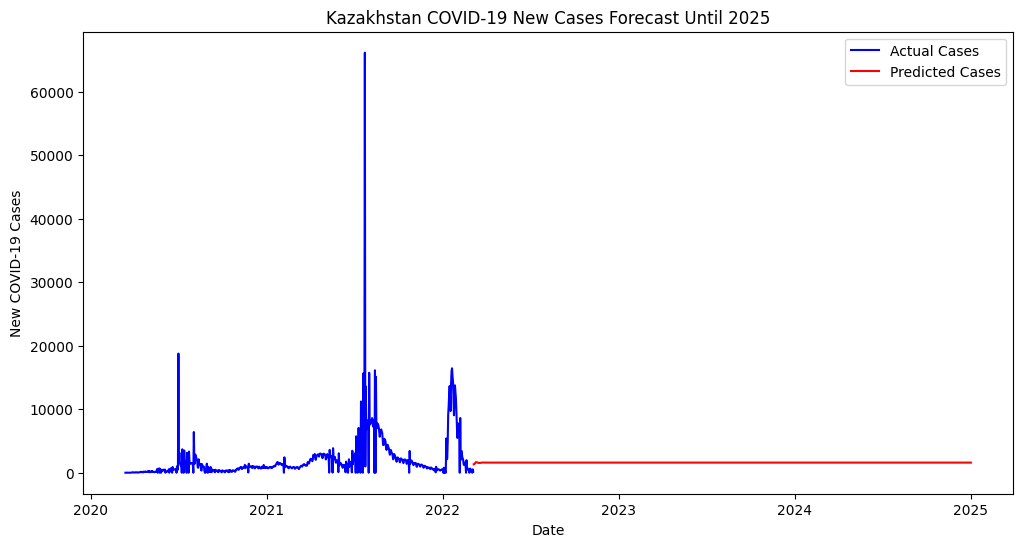

In [31]:
# 9. Plot the Results
# -------------------
# Plot both the actual new cases and the forecasted values.
plt.figure(figsize=(12, 6))
plt.plot(df_ka['date'], df_ka['new_cases'], label='Actual Cases', color='blue')
plt.plot(forecast_df['date'], forecast_df['predicted_new_cases'], label='Predicted Cases', color='red')
plt.xlabel("Date")
plt.ylabel("New COVID-19 Cases")
plt.title("Kazakhstan COVID-19 New Cases Forecast Until 2025")
plt.legend()
plt.show()